In [1]:
import h5py
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class CERNJetUnlabelledDataset(Dataset):
    def __init__(self, file_path, transform=None):
        """
        Args:
            file_path (string): Path to the .h5 file.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.file_path = file_path
        self.transform = transform
        self.dataset = None
        self.h5_file = None
        
        # Open briefly just to get the dataset length and keys
        with h5py.File(self.file_path, 'r') as f:
            self.keys = list(f.keys())
            print(f"Detected keys in .h5 file: {self.keys}")
            
            # Assuming the primary data is under the first key (e.g., 'X', 'data', or 'jets')
            # You may need to change self.keys[0] to the exact string name if there are multiple keys.
            self.data_key = self.keys[0] 
            self.length = len(f[self.data_key])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Multiprocessing safeguard: Open the file ONLY if a worker doesn't have it open yet
        if self.h5_file is None:
            self.h5_file = h5py.File(self.file_path, 'r')
            self.dataset = self.h5_file[self.data_key]

        # Read the specific image array at this index
        img = self.dataset[idx] 
        
        # Convert to a PyTorch FloatTensor
        img = torch.tensor(img, dtype=torch.float32)

        # PyTorch expects channels first: (Channels, Height, Width)
        # If the data comes in as (125, 125, 8), we permute it to (8, 125, 125)
        if img.shape[-1] == 8:
            img = img.permute(2, 0, 1)

        img = torch.log1p(img)

        # --- The Crucial XCiT Padding Step ---
        # Pad from 125x125 to 128x128 so it divides cleanly by patch_size 8 or 16
        # F.pad format for 2D is (pad_left, pad_right, pad_top, pad_bottom)
        # We add 1 pixel left/top, and 2 pixels right/bottom (1+2=3 pixels total)
        img = F.pad(img, (1, 2, 1, 2), mode='constant', value=0.0)

        # Apply any normalizations if provided
        if self.transform:
            img = self.transform(img)

        return img

    def __del__(self):
        # Clean up the file handle when the dataset is destroyed
        if self.h5_file is not None:
            self.h5_file.close()

In [2]:
# Assuming standard Kaggle/Colab input path structure
DATA_PATH = '/kaggle/input/datasets/happysaxena/cern-unlabelled-data/Dataset_Specific_Unlabelled.h5'
# If the path is relative to your working directory, just use the folder name:
# DATA_PATH = 'cern_unlabelled_data/Dataset_Specific_Unlabelled.h5'

# Initialize Dataset
unlabelled_dataset = CERNJetUnlabelledDataset(file_path=DATA_PATH)

# Initialize Dataloader
# batch_size=64 is a good starting point for XCiT if you have a T4 or P100 GPU
train_loader = DataLoader(
    unlabelled_dataset, 
    batch_size=64, 
    shuffle=True, 
    num_workers=2, # Set to 2 or 4 for faster loading
    pin_memory=True # Speeds up transfer to GPU
)

# Test it out to verify shapes
for batch in train_loader:
    print(f"Batch shape: {batch.shape}") # Should print: torch.Size([64, 8, 128, 128])
    break

Detected keys in .h5 file: ['jet']
Batch shape: torch.Size([64, 8, 128, 128])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- UTILITIES ---
def to_2tuple(x):
    return x if isinstance(x, tuple) else (x, x)

class DropPath(nn.Module):
    """Stochastic Depth (DropPath) implementation to avoid `timm` dependency."""
    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        return x.div(keep_prob) * random_tensor

class Mlp(nn.Module):
    """Standard Feed-Forward Network"""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class CPE(nn.Module):
    """Conditional Positional Encoding using a 3x3 depthwise convolution."""
    def __init__(self, dim, k=3):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim, kernel_size=k, stride=1, padding=k//2, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        # Reshape to 2D image format (B, C, H, W)
        feat = x.transpose(1, 2).contiguous().view(B, C, H, W)
        feat = self.proj(feat)
        # Flatten back to sequence (B, N, C)
        feat = feat.flatten(2).transpose(1, 2)
        return x + feat

# --- TEST STEP 1 ---
if __name__ == "__main__":
    dummy_x = torch.randn(2, 3136, 96) # Batch=2, Seq=3136 (56x56), Dim=96
    cpe = CPE(dim=96)
    out = cpe(dummy_x, size=(56, 56))
    print("Step 1 (CPE) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 1 (CPE) Output Shape: torch.Size([2, 3136, 96])


In [4]:
class ConvStem(nn.Module):
    """Initial Convolutional Stem: Downsamples image by 4x."""
    def __init__(self, in_chans, embed_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        return self.proj(x)

class PatchEmbed(nn.Module):
    """Acts as the Stem (Stage 0) or Downsampler (Stages 1, 2, 3)."""
    def __init__(self, patch_size=16, in_chans=3, embed_dim=96, is_stem=False):
        super().__init__()
        self.patch_size = to_2tuple(patch_size)
        self.is_stem = is_stem
        
        if self.is_stem: # Stage 0
            self.proj = ConvStem(in_chans, embed_dim)
            self.norm = nn.LayerNorm(embed_dim)
        else: # Patch Merging between stages
            self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=2, stride=2)
            self.norm = nn.LayerNorm(in_chans)

    def forward(self, x, size=None):
        if len(x.shape) == 3: # If input is a sequence (B, L, C)
            B, HW, C = x.shape
            H, W = size
            x = self.norm(x)
            x = x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        x = self.proj(x)
        newsize = (x.size(2), x.size(3))
        x = x.flatten(2).transpose(1, 2)
        
        if self.is_stem:
            x = self.norm(x)
        return x, newsize

# --- TEST STEP 2 ---
if __name__ == "__main__":
    dummy_img = torch.randn(2, 3, 224, 224) # Standard 224x224 image
    stem = PatchEmbed(patch_size=4, in_chans=3, embed_dim=96, is_stem=True)
    out, newsize = stem(dummy_img)
    print(f"Step 2 (Stem) Output Shape: {out.shape}, New Grid Size: {newsize}") 
    # Expected: [2, 3136, 96], Size: (56, 56)

Step 2 (Stem) Output Shape: torch.Size([2, 3136, 96]), New Grid Size: (56, 56)


In [5]:
def window_partition(x, window_size: int):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size: int, H: int, W: int):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    """Standard Self-Attention restricted to local windows."""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(x)

class LWABlock(nn.Module):
    """Local Window Attention Block"""
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.cpe = nn.ModuleList([CPE(dim), CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        H, W = size
        B, L, C = x.shape

        shortcut = self.cpe[0](x, size)
        x = self.norm1(shortcut).view(B, H, W, C)

        # Pad feature maps if they aren't divisible by window_size
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b))
        _, Hp, Wp, _ = x.shape

        # Partition -> Attend -> Reverse
        x_windows = window_partition(x, self.window_size).view(-1, self.window_size**2, C)
        attn_windows = self.attn(x_windows)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, Hp, Wp)

        # Remove padding
        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = shortcut + self.drop_path(x.view(B, H * W, C))
        
        # FFN Part
        x = self.cpe[1](x, size)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 3 ---
if __name__ == "__main__":
    lwa = LWABlock(dim=96, num_heads=3)
    out, _ = lwa(out, newsize) # Uses outputs from Step 2
    print("Step 3 (LWA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 3 (LWA Block) Output Shape: torch.Size([2, 3136, 96])


In [6]:
class LinearAttention(nn.Module):
    """O(N) Complexity Attention mechanism"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        # Learnable temperature to replace Softmax normalization effect
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1) * self.scale)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # ReLU mapping ensures non-negativity (crucial for Linear Attention)
        q = self.act(q)
        k = self.act(k)
        
        # Calculate K^T * V first! (This is where O(N^2) becomes O(N))
        kv = (k.transpose(-2, -1) @ v) * self.temperature
        
        # Calculate denominator and clamp to prevent dividing by zero
        k_sum = k.transpose(-2, -1).sum(dim=-1, keepdim=True)
        denom = torch.clamp(q @ k_sum, min=1e-2)

        attn = (q @ kv) / denom
        
        x = attn.transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

class LCM(nn.Module):
    """Local Concentration Module: Refocuses linear attention locally."""
    def __init__(self, dim, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)
        self.act = nn.GELU()
        self.bn = nn.BatchNorm2d(dim)
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        x = x.transpose(-1, -2).contiguous().view(B, C, H, W)
        x = self.conv2(self.bn(self.act(self.conv1(x))))
        return x.flatten(2).transpose(-1, -2)

class LGABlock(nn.Module):
    """Linear Global Attention Block"""
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.cpe = nn.ModuleList([CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        
        self.norm3 = nn.LayerNorm(dim)
        self.local_mp = LCM(dim)
        
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        # 1. CPE & Linear Attn
        x = self.cpe[0](x, size)
        cur = self.attn(self.norm1(x))
        x = x + self.drop_path(cur)
        
        # 2. LCM
        x = x + self.drop_path(self.local_mp(self.norm3(x), size))
        
        # 3. FFN
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 4 ---
if __name__ == "__main__":
    lga = LGABlock(dim=96, num_heads=3)
    out, _ = lga(out, newsize)
    print("Step 4 (LGA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 4 (LGA Block) Output Shape: torch.Size([2, 3136, 96])


In [7]:

import torch
import torch.nn as nn

class L2ViT_Tiny_CERN(nn.Module):
    """L2ViT-Tiny adapted for CERN Task 2h: 
       Simultaneous Classification + Mass Regression (+ optional Momentum Regression)
    """
    def __init__(self, in_chans=3, num_classes=2, drop_path_rate=0.1, include_momentum=False):
        super().__init__()
        self.include_momentum = include_momentum
        
        # L2ViT-Tiny Configurations
        depths = [2, 2, 6, 2]
        dims =[96, 192, 384, 768]
        num_heads =[3, 6, 12, 24]
        
        # 1. Patch Embeddings (Downsampling layers)
        self.downsample_layers = nn.ModuleList()
        for i in range(4):
            embed = PatchEmbed(
                patch_size=4 if i == 0 else 2,
                in_chans=in_chans if i == 0 else dims[i - 1],
                embed_dim=dims[i],
                is_stem=(i == 0)
            )
            self.downsample_layers.append(embed)

        # 2. Transformer Stages
        self.stages = nn.ModuleList()
        dp_rates =[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))] 
        cur = 0
        
        for i in range(4):
            blocks =[]
            for j in range(depths[i]):
                # Alternating LWA and LGA blocks
                if j % 2 == 0:
                    blocks.append(LWABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
                else:
                    blocks.append(LGABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
            self.stages.append(nn.ModuleList(blocks))
            cur += depths[i]

        # 3. Final Norm and Global Average Pooling
        self.norm = nn.LayerNorm(dims[-1])
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 4. Task 2h Specific Heads
        # Base tasks: Classification and Mass Regression
        self.cls_head = nn.Linear(dims[-1], num_classes) # Particle ID
        self.mass_head = nn.Linear(dims[-1], 1)          # Mass Regression
        
        # Optional task: Momentum Regression
        if self.include_momentum:
            self.mom_head = nn.Linear(dims[-1], 1)   
            
    # Momentum Regression
    def forward_features(self, x):
        size = [x.size(2), x.size(3)]
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
        x = self.norm(x)
        B, N, C = x.shape
        H, W = size
        return x.transpose(1, 2).view(B, C, H, W)

    def forward(self, x):
        size =[x.size(2), x.size(3)]
        
        # Pass through the 4 hierarchical stages
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
                
        # Aggregate global features
        x = self.norm(x)
        x = self.avgpool(x.transpose(1, 2)).flatten(1) # Final shape: (Batch, 768)
        
        # Base Output Dictionary
        outputs = {
            'class_logits': self.cls_head(x),
            'mass_pred': self.mass_head(x)
        }
        
        # Add momentum prediction if the head was initialized
        if self.include_momentum:
            outputs['mom_pred'] = self.mom_head(x)
            
        return outputs

# --- TEST FINAL FLOW ---
if __name__ == "__main__":
    print("\n--- FINAL MODEL VALIDATION ---")
    
    # Random batch of Images (Batch=4, Channels=3, H=224, W=224)
    # Note: Check your .h5 file for the exact number of channels the CERN data uses!
    dummy_input = torch.randn(4, 3, 224, 224)
    
    print("\nTest 1: Strategy A (Classification + Mass only)")
    model_A = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=False)
    outputs_A = model_A(dummy_input)
    print("Keys in output:", outputs_A.keys())
    print("Class Output Shape:", outputs_A['class_logits'].shape) # Expected:[4, 2]
    print("Mass Output Shape:", outputs_A['mass_pred'].shape)     # Expected: [4, 1]
    
    print("\nTest 2: Strategy B (Classification + Mass + Momentum)")
    model_B = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=True)
    outputs_B = model_B(dummy_input)
    print("Keys in output:", outputs_B.keys())
    print("Class Output Shape:", outputs_B['class_logits'].shape) # Expected: [4, 2]
    print("Mass Output Shape:", outputs_B['mass_pred'].shape)     # Expected:[4, 1]
    print("Mom Output Shape:", outputs_B['mom_pred'].shape)       # Expected:[4, 1]
    print("\nForward Pass Successful for both strategies!")


--- FINAL MODEL VALIDATION ---

Test 1: Strategy A (Classification + Mass only)
Keys in output: dict_keys(['class_logits', 'mass_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])

Test 2: Strategy B (Classification + Mass + Momentum)
Keys in output: dict_keys(['class_logits', 'mass_pred', 'mom_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])
Mom Output Shape: torch.Size([4, 1])

Forward Pass Successful for both strategies!


In [9]:

import h5py
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split


class CERNLabelledDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        self.h5_file = None
        
        # Open briefly to verify total length
        with h5py.File(self.file_path, 'r') as f:
            self.length = len(f['Y'])
            print(f"Loaded dataset with {self.length} total labelled jets.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Multiprocessing safeguard for HDF5
        if self.h5_file is None:
            self.h5_file = h5py.File(self.file_path, 'r')
            self.jets = self.h5_file['jet']
            self.Y = self.h5_file['Y']
            self.m = self.h5_file['m']
            self.pT = self.h5_file['pT']

        # --- 1. Process the Image ---
        img = self.jets[idx] 
        img = torch.tensor(img, dtype=torch.float32)

        if img.shape[-1] == 8:
            img = img.permute(2, 0, 1)

        # Image features are also log-transformed to stabilize input
        img = torch.log1p(img)
        img = F.pad(img, (1, 2, 1, 2), mode='constant', value=0.0)

        # --- 2. Process Classification Label ---
        y_class = torch.tensor(self.Y[idx], dtype=torch.long) 
        
        # --- 3. LOG TRANSFORMATION FOR REGRESSION TARGETS ---
        # We use log1p (ln(1+x)) to handle any zero values safely.
        # This turns skewed distributions into roughly Gaussian-shaped ones.
        raw_mass = self.m[idx]
        raw_pt = self.pT[idx]
        
        y_mass = torch.tensor(np.log1p(raw_mass), dtype=torch.float32)
        y_pt = torch.tensor(np.log1p(raw_pt), dtype=torch.float32)

        return img, y_class, y_mass, y_pt

    def __del__(self):
        if self.h5_file is not None:
            self.h5_file.close()

# --- DATALOADER CREATION ---
LABELLED_DATA_PATH = '/kaggle/input/datasets/happysaxena/cern-labelled-2/Dataset_Specific_labelled_full_only_for_2i.h5'
full_dataset = CERNLabelledDataset(LABELLED_DATA_PATH)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

batch_size = 32
train_loader_post = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_post = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Updated Sanity Check ---
print("\n--- Dataloader Sanity Check (Log-Transformed) ---")
for imgs, classes, masses, pts in train_loader_post:
    print(f"Images Shape:  {imgs.shape}")
    # print(f"Classes Range: {classes.min().item()} to {classes.max().item()}")
    print(f"Masses (Logged) Mean/Std: {masses.mean():.4f} / {masses.std():.4f}")
    print(f"pT (Logged) Mean/Std:     {pts.mean():.4f} / {pts.std():.4f}")
    break



Loaded dataset with 10000 total labelled jets.

--- Dataloader Sanity Check (Log-Transformed) ---
Images Shape:  torch.Size([32, 8, 128, 128])
Masses (Logged) Mean/Std: 4.8724 / 0.4166
pT (Logged) Mean/Std:     6.2537 / 0.1469


Loading pretrained backbone...
Starting Triple-Task Fine-Tuning (Cls + Mass + Mom) on cuda...


Train Epoch 1/50:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1 | Val Loss: 0.7572 | Val Acc: 69.50%
         | R2 Mass: 0.3802 | R2 Mom: -0.1933
  --> Improved! Best model weights updated.


Train Epoch 2/50:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2 | Val Loss: 0.3303 | Val Acc: 90.00%
         | R2 Mass: 0.7422 | R2 Mom: 0.0530
  --> Improved! Best model weights updated.


...

Epoch 11 | Val Loss: 0.3154 | Val Acc: 90.05%
         | R2 Mass: 0.7976 | R2 Mom: 0.3911


Train Epoch 12/50:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 12 | Val Loss: 0.3231 | Val Acc: 90.75%
         | R2 Mass: 0.7976 | R2 Mom: 0.4118


Train Epoch 13/50:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 13 | Val Loss: 0.3509 | Val Acc: 90.45%
         | R2 Mass: 0.7955 | R2 Mom: 0.3247
Early stopping at epoch 13!


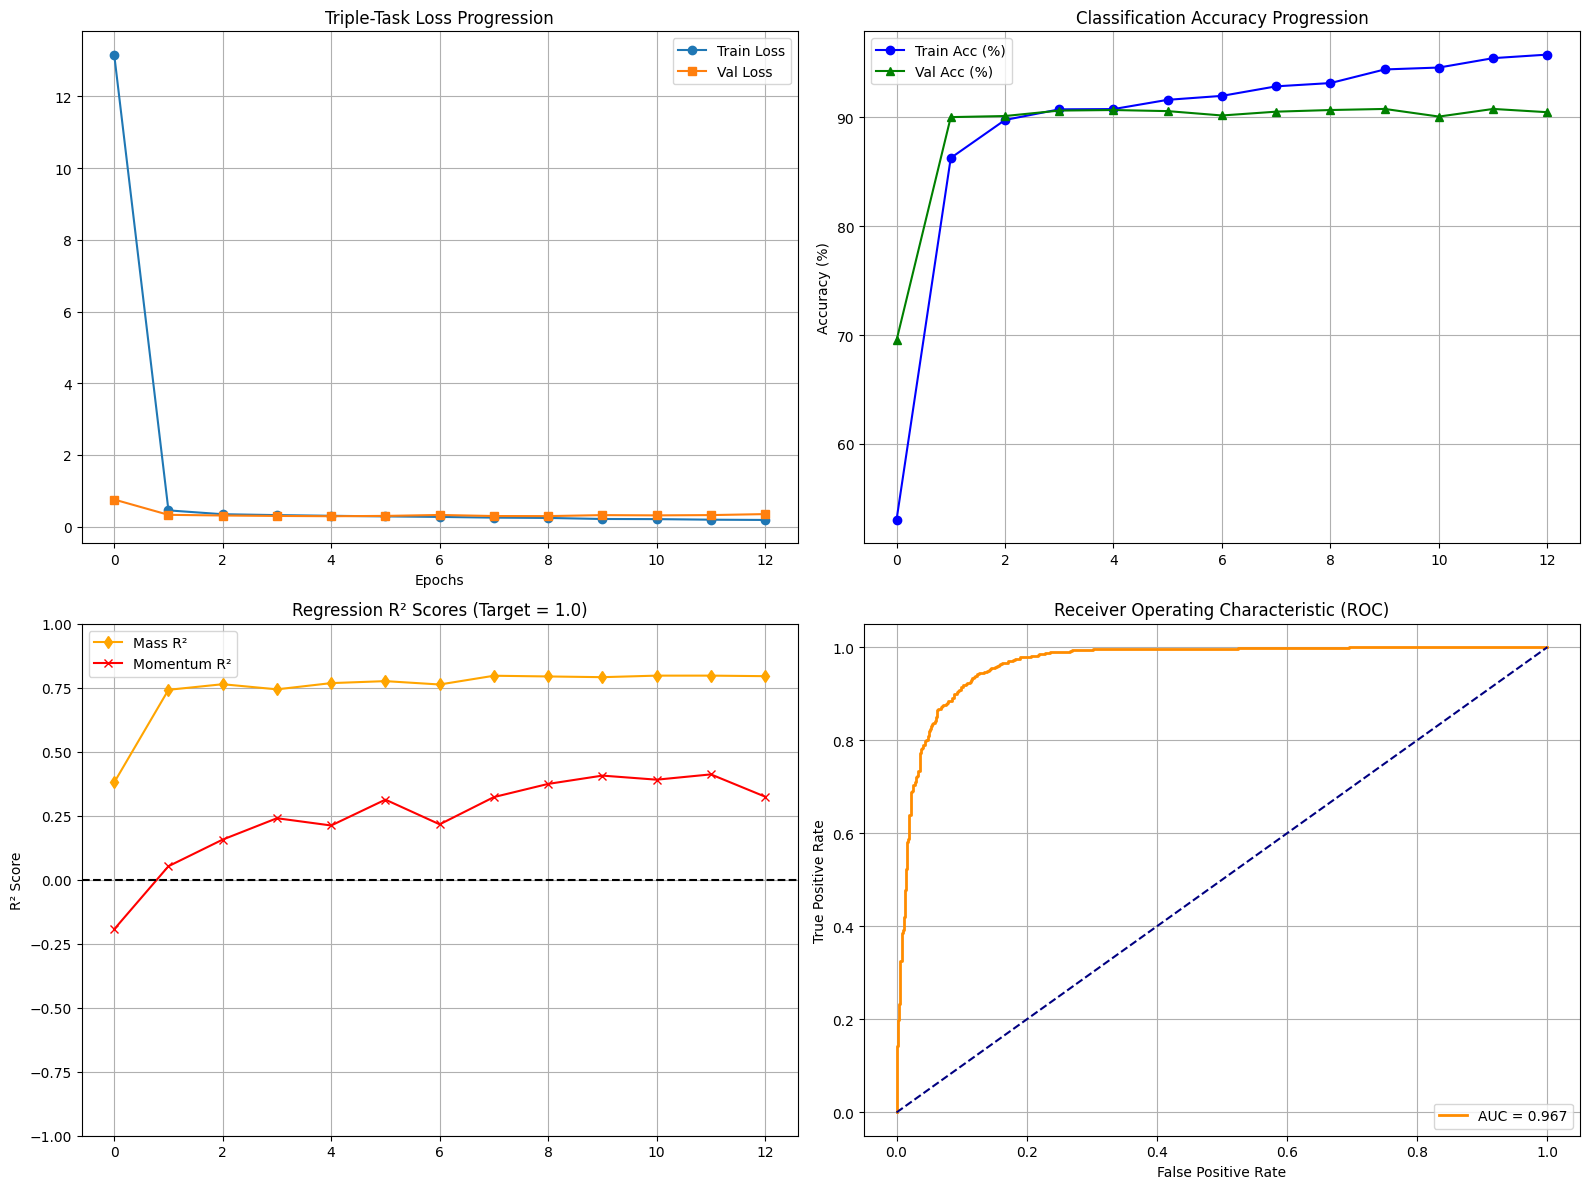

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import copy
import numpy as np
from sklearn.metrics import r2_score, roc_curve, auc

# ==========================================
# 1. MULTI-TASK LOSS WRAPPER (3 Tasks)
# ==========================================
class CERNMultiTaskLoss(nn.Module):
    def __init__(self, lambda_cls=1.0, lambda_mass=1.0, lambda_mom=0.1):
        super().__init__()
        self.criterion_cls = nn.CrossEntropyLoss()
        self.criterion_reg = nn.MSELoss()
        
        self.lambda_cls = lambda_cls
        self.lambda_mass = lambda_mass
        self.lambda_mom = lambda_mom

    def forward(self, outputs, targets):
        # 1. Classification
        cls_target = targets['cls']
        if cls_target.dim() > 1 and cls_target.shape[1] > 1:
            cls_target = torch.argmax(cls_target, dim=1)
        else:
            cls_target = cls_target.view(-1)
        loss_cls = self.criterion_cls(outputs['class_logits'], cls_target)
        
        # 2. Mass Regression
        loss_mass = self.criterion_reg(outputs['mass_pred'].view(-1), targets['mass'].view(-1))
        
        # 3. Momentum Regression
        loss_mom = self.criterion_reg(outputs['mom_pred'].view(-1), targets['mom'].view(-1))
        
        # Total Weighted Loss
        total_loss = (self.lambda_cls * loss_cls) + \
                     (self.lambda_mass * loss_mass) + \
                     (self.lambda_mom * loss_mom)
                     
        return total_loss, loss_cls, loss_mass, loss_mom


# ==========================================
# 2. FINE-TUNING LOOP (3 Tasks + Metrics)
# ==========================================
def run_finetuning(model, train_loader, val_loader, epochs=30, lr=1e-4, early_stop_patience=7, device='cuda'):
    print(f"Starting Triple-Task Fine-Tuning (Cls + Mass + Mom) on {device}...")
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # We weight momentum slightly less (0.5) if it is harder to converge, 
    # but you can keep them all at 1.0 initially.
    criterion = CERNMultiTaskLoss(lambda_cls=1.0, lambda_mass=1.0, lambda_mom=1.0)
    
    history = {
        'train_loss':[], 'val_loss':[], 
        'train_acc': [], 'val_acc':[],    
        'val_r2_mass':[], 'val_r2_mom':[]
    }
    
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_roc_data = {} 
    
    for epoch in range(epochs):
        # ------------------- TRAIN -------------------
        model.train()
        train_loss = 0.0
        train_correct_cls, train_total_cls = 0, 0 
        
        progress_bar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{epochs}")
        for images, labels_cls, labels_mass, labels_mom in progress_bar:
            images = images.to(device)
            targets = {
                'cls': labels_cls.to(device, dtype=torch.long), 
                'mass': labels_mass.to(device, dtype=torch.float32),
                'mom': labels_mom.to(device, dtype=torch.float32)
            }
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # Unpack 4 losses
            loss, l_cls, l_mass, l_mom = criterion(outputs, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            
            with torch.no_grad():
                # Accuracy tracking
                cls_target_acc = targets['cls']
                if cls_target_acc.dim() > 1 and cls_target_acc.shape[1] > 1:
                    cls_target_acc = torch.argmax(cls_target_acc, dim=1)
                else:
                    cls_target_acc = cls_target_acc.view(-1)
                
                _, predicted = torch.max(outputs['class_logits'], 1)
                train_total_cls += cls_target_acc.size(0)
                train_correct_cls += (predicted == cls_target_acc).sum().item()
            
            progress_bar.set_postfix({'Loss': f"{loss.item():.3f}"})
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct_cls / train_total_cls  
        
        # ------------------- VALIDATION -------------------
        model.eval()
        val_loss = 0.0
        correct_cls, total_cls = 0, 0
        
        val_cls_true, val_cls_probs = [], []
        val_mass_true, val_mass_pred = [], []
        val_mom_true, val_mom_pred = [], []
        
        with torch.no_grad():
            for images, labels_cls, labels_mass, labels_mom in val_loader:
                images = images.to(device)
                targets = {
                    'cls': labels_cls.to(device, dtype=torch.long), 
                    'mass': labels_mass.to(device, dtype=torch.float32),
                    'mom': labels_mom.to(device, dtype=torch.float32)
                }
                
                outputs = model(images)
                loss, _, _, _ = criterion(outputs, targets)
                val_loss += loss.item()
                
                # Setup Classification Metrics
                cls_target_acc = targets['cls']
                if cls_target_acc.dim() > 1 and cls_target_acc.shape[1] > 1:
                    cls_target_acc = torch.argmax(cls_target_acc, dim=1)
                else:
                    cls_target_acc = cls_target_acc.view(-1)
                
                _, predicted = torch.max(outputs['class_logits'], 1)
                probs = torch.softmax(outputs['class_logits'], dim=1)[:, 1] 
                
                total_cls += cls_target_acc.size(0)
                correct_cls += (predicted == cls_target_acc).sum().item()
                
                val_cls_true.extend(cls_target_acc.cpu().numpy())
                val_cls_probs.extend(probs.cpu().numpy())
                
                # Regression Tracking
                val_mass_true.extend(targets['mass'].view(-1).cpu().numpy())
                val_mass_pred.extend(outputs['mass_pred'].view(-1).cpu().numpy())
                val_mom_true.extend(targets['mom'].view(-1).cpu().numpy())
                val_mom_pred.extend(outputs['mom_pred'].view(-1).cpu().numpy())
                
        # Calculate Validation Epoch Metrics
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_cls / total_cls
        epoch_r2_mass = r2_score(val_mass_true, val_mass_pred)
        epoch_r2_mom = r2_score(val_mom_true, val_mom_pred)
        
        scheduler.step(avg_val_loss)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_r2_mass'].append(epoch_r2_mass)
        history['val_r2_mom'].append(epoch_r2_mom)
        
        print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"         | R2 Mass: {epoch_r2_mass:.4f} | R2 Mom: {epoch_r2_mom:.4f}")
        
        # ------------------- EARLY STOPPING -------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            best_roc_data = {'true': val_cls_true, 'probs': val_cls_probs}
            print("  --> Improved! Best model weights updated.")
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1}!")
                break

    model.load_state_dict(best_model_weights)
    return model, history, best_roc_data


# ==========================================
# 3. COMPREHENSIVE PLOTTER (4 Subplots)
# ==========================================
def plot_finetuning_results(history, roc_data):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Total Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0, 0].set_title('Triple-Task Loss Progression')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # 2. Classification Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc (%)', color='blue', marker='o') 
    axes[0, 1].plot(history['val_acc'], label='Val Acc (%)', color='green', marker='^')
    axes[0, 1].set_title('Classification Accuracy Progression')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 3. R2 Scores (Mass and Momentum)
    axes[1, 0].plot(history['val_r2_mass'], label='Mass R²', color='orange', marker='d')
    axes[1, 0].plot(history['val_r2_mom'], label='Momentum R²', color='red', marker='x')
    axes[1, 0].set_title('Regression R² Scores (Target = 1.0)')
    axes[1, 0].set_ylabel('R² Score')
    axes[1, 0].set_ylim([-1.0, 1.0]) 
    axes[1, 0].axhline(0, color='black', linestyle='--') 
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # 4. ROC Curve
    fpr, tpr, _ = roc_curve(roc_data['true'], roc_data['probs'])
    roc_auc = auc(fpr, tpr)
    axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1, 1].plot([0, 1], [0, 1], color='navy', linestyle='--') 
    axes[1, 1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(loc="lower right")
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('triple_task_metrics.png')
    plt.show()


# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Init Model with ALL tasks enabled
    model = L2ViT_Tiny_CERN(in_chans=8, num_classes=2, include_momentum=True)
    
    # 2. Load Pretrained Backbone
    pretrained_path = '/kaggle/input/datasets/saxenaitis/l2vit-weights/l2vit_tiny_cern_pretrained.pth'
    if os.path.exists(pretrained_path):
        print("Loading pretrained backbone...")
        state_dict = torch.load(pretrained_path, map_location=device)
        model.load_state_dict(state_dict, strict=False)
        
    model = model.to(device)
    
    # 3. Fine-Tune
    finetuned_model, history, best_roc_data = run_finetuning(
        model, 
        train_loader_post, 
        val_loader_post, 
        epochs=50,             
        lr=5e-5, # Slightly lower LR for 3 tasks to ensure stability
        early_stop_patience=8, 
        device=device
    )
    
    plot_finetuning_results(history, best_roc_data)
    torch.save(finetuned_model.state_dict(), 'l2vit_cern_triple_task_best.pth')